# Tesla EV — End-to-End ML Pipeline on Sales/Price Data

1. Data Cleaning & Inspection  
2. Exploratory Data Analysis (EDA)  
3. Feature Engineering  
4. Encoding & Feature Scaling  
5. Regression Modeling (Linear, Ridge, Lasso)  
6. Cross-Validation & Hyperparameter Tuning  
7. Time-Series Forecasting (decomposition, stationarity, lag features, ARIMA)

**Target variable:** `Estimated_Deliveries` (a continuous number → this is a **supervised regression** problem).


## 1. Imports

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Time series
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

## 2. Data Loading & Inspection

We load the dataset and take a first look at its size, columns, and data types.

In [33]:
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [34]:
print("Dataset shape:", df.shape)

Dataset shape: (2640, 12)


In [35]:
print("Dataset Information:\n")
df.info()

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [36]:
# Statistical summary of numeric columns
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


## 3. Data Cleaning

We check for missing values and duplicate rows. A clean dataset is the foundation of any reliable model.

In [37]:
# Missing values per column
df.isnull().sum()

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

In [38]:
# Duplicate rows
df.duplicated().sum()

0

## 4. Exploratory Data Analysis (EDA)

explore the distribution of the target and how it relates to other variables.

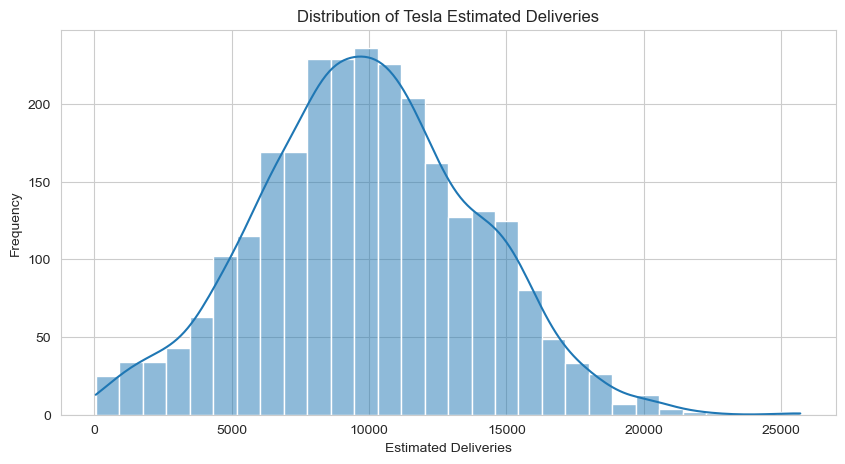

In [39]:
# Distribution of the target variable
plt.figure(figsize=(10,5))

sns.histplot(df["Estimated_Deliveries"], bins=30, kde=True)

plt.title("Distribution of Tesla Estimated Deliveries")
plt.xlabel("Estimated Deliveries")
plt.ylabel("Frequency")
plt.show()

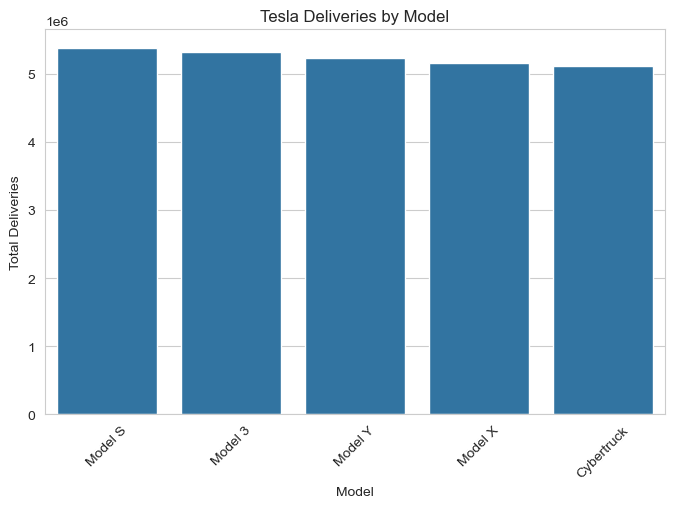

In [40]:
# Total deliveries by model
model_sales = df.groupby("Model")["Estimated_Deliveries"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=model_sales.index, y=model_sales.values)

plt.title("Tesla Deliveries by Model")
plt.xlabel("Model")
plt.ylabel("Total Deliveries")
plt.xticks(rotation=45)
plt.show()

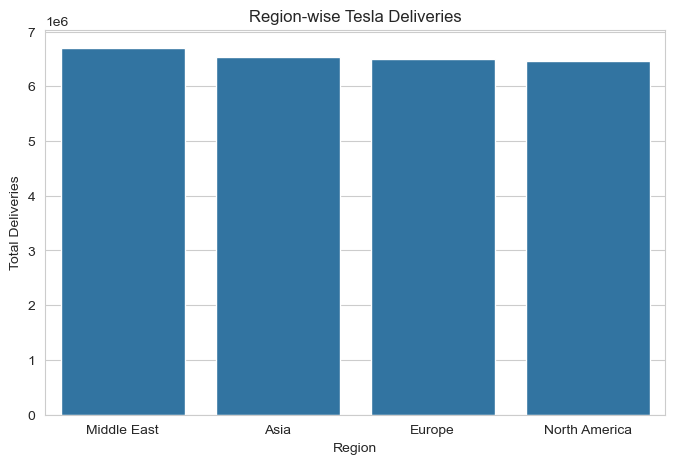

In [41]:
# Total deliveries by region
region_sales = df.groupby("Region")["Estimated_Deliveries"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=region_sales.index, y=region_sales.values)
plt.title("Region-wise Tesla Deliveries")
plt.xlabel("Region"); plt.ylabel("Total Deliveries")
plt.show()

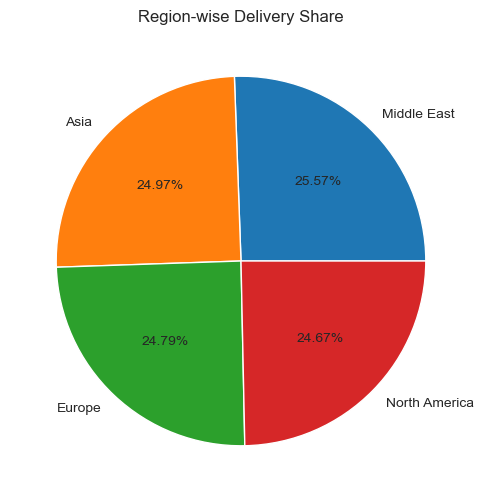

In [43]:
# Region share (pie)
region_sales.plot(kind="pie", autopct="%.2f%%", figsize=(6,6))
plt.title("Region-wise Delivery Share")
plt.ylabel("")
plt.show()

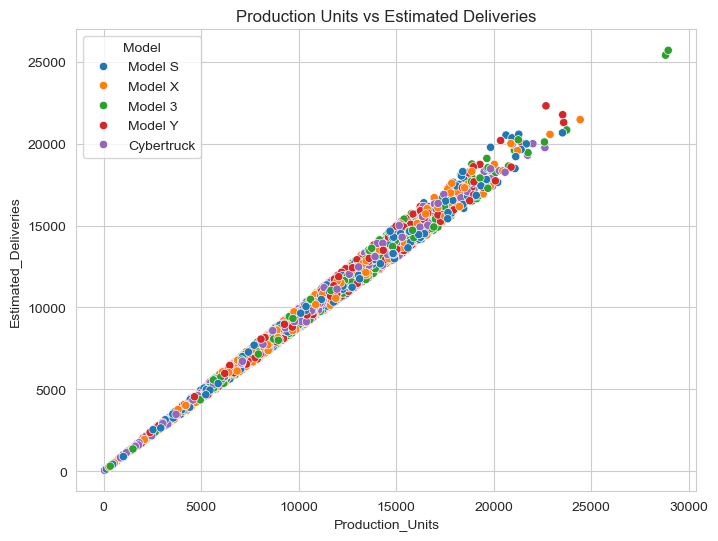

In [44]:
# Production vs Deliveries (the strongest relationship)
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="Production_Units", y="Estimated_Deliveries", hue="Model")
plt.title("Production Units vs Estimated Deliveries")
plt.show()

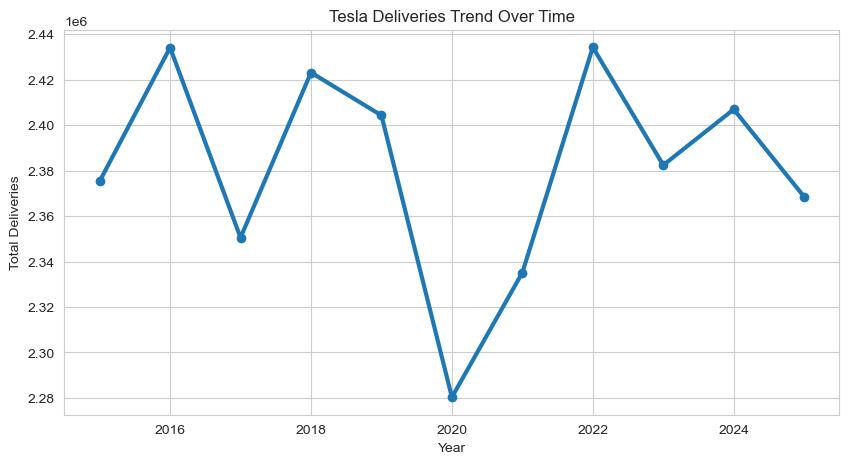

In [45]:
# Deliveries trend over the years
yearly_sales = df.groupby("Year")["Estimated_Deliveries"].sum()

plt.figure(figsize=(10,5))
plt.plot(yearly_sales.index, yearly_sales.values, marker="o", linewidth=3)

plt.title("Tesla Deliveries Trend Over Time")
plt.xlabel("Year"); plt.ylabel("Total Deliveries")
plt.grid(True)
plt.show()

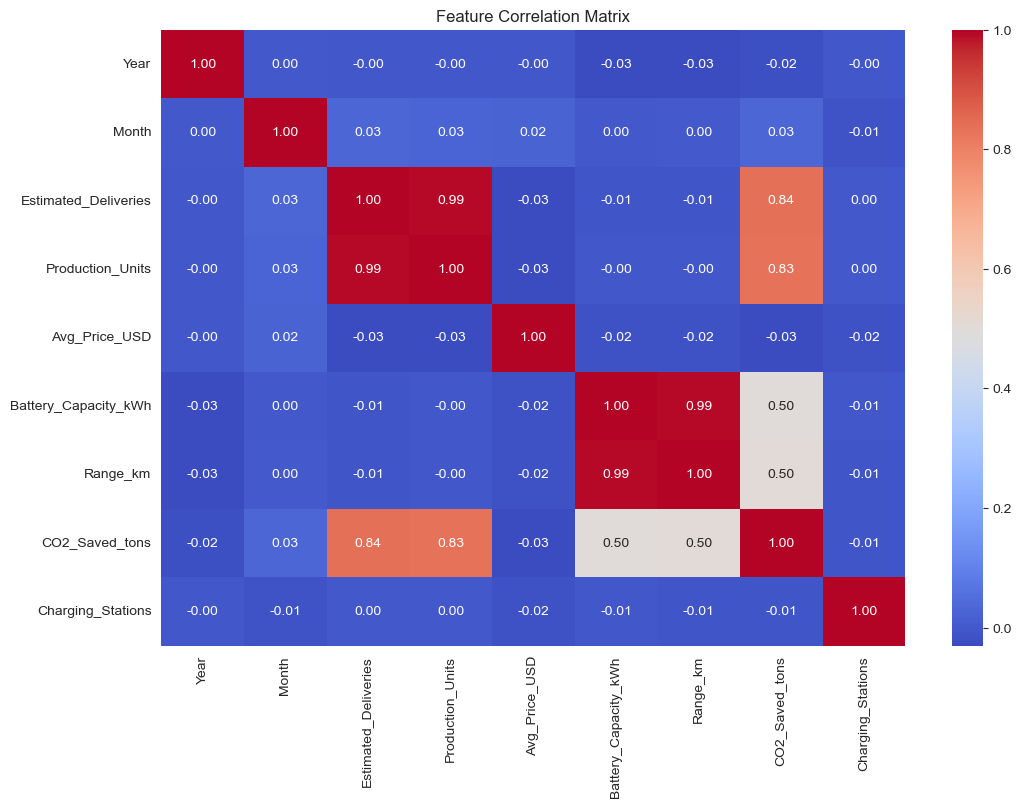

In [46]:
# Correlation heatmap (numeric columns only)
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()

In [47]:
# Correlation of each feature with the target
df.corr(numeric_only=True)["Estimated_Deliveries"].sort_values(ascending=False)

Estimated_Deliveries    1.000000
Production_Units        0.994234
CO2_Saved_tons          0.836814
Month                   0.030877
Charging_Stations       0.000753
Year                   -0.002863
Range_km               -0.006606
Battery_Capacity_kWh   -0.007765
Avg_Price_USD          -0.027546
Name: Estimated_Deliveries, dtype: float64

**Key EDA insight:** `Production_Units` is almost perfectly correlated with `Estimated_Deliveries`. The remaining numeric features (Year, Month, Price, Battery, Range, Charging) have almost no linear relationship with deliveries.

## 5. Feature Engineering

create new features that may help the model and a `Date` column needed for the time-series stage.

> **Data Leakage note:** `Production_Efficiency = Deliveries / Production` is built from the **target**, so using it as a model input would leak the answer. created it only for inspection and exclude it from the features. `Price_per_KM` is safe (it uses no target information), so we keep it.

In [48]:
# Safe feature
df["Price_per_KM"] = df["Avg_Price_USD"] / df["Range_km"]

# Leaky feature 
df["Production_Efficiency"] = df["Estimated_Deliveries"] / df["Production_Units"]

# used later in time-series forecasting
df["Date"] = pd.to_datetime(df["Year"].astype(str) + "-" + df["Month"].astype(str), format="%Y-%m")

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Price_per_KM,Production_Efficiency,Date
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207,131.923679,0.984600,2023-05-01
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640,142.022032,0.911864,2015-02-01
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071,245.598583,0.915334,2019-01-01
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333,125.414199,0.896594,2021-02-01
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722,173.747020,0.914087,2016-12-01


## 6. Encoding Categorical Features (One-Hot)

`Region`, `Model`, and `Source_Type` are **nominal** categories — they have no natural order. We use **One-Hot Encoding** (not Label Encoding) so the model does not assume a false ordering between categories (e.g. that "Europe" > "Asia"). `drop_first=True` removes one redundant column per category to avoid multicollinearity.

In [17]:
df_encoded = pd.get_dummies(df, columns=["Region", "Model", "Source_Type"], drop_first=True)
df_encoded.head()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations,Price_per_KM,...,Date,Region_Europe,Region_Middle East,Region_North America,Model_Model 3,Model_Model S,Model_Model X,Model_Model Y,Source_Type_Interpolated (Month),Source_Type_Official (Quarter)
0,2023,5,17646,17922,92874.27,120,704,1863.42,12207,131.923679,...,2023-05-01,True,False,False,False,True,False,False,True,False
1,2015,2,3797,4164,62205.65,75,438,249.46,7640,142.022032,...,2015-02-01,False,False,False,False,False,True,False,False,True
2,2019,1,8411,9189,117887.32,82,480,605.59,14071,245.598583,...,2019-01-01,False,False,True,False,False,True,False,True,False
3,2021,2,6555,7311,89294.91,120,712,700.07,9333,125.414199,...,2021-02-01,False,False,True,True,False,False,False,False,True
4,2016,12,12374,13537,114846.78,120,661,1226.88,8722,173.747020,...,2016-12-01,False,True,False,False,False,False,True,False,False


## 7. Defining Features (X) and Target (y)

- `Estimated_Deliveries` → the target itself  
- `CO2_Saved_tons` and `Production_Efficiency` → **leaky** (both derived from the target)  
- `Date` → a datetime column, kept aside for the time-series section

In [49]:
X = df_encoded.drop(columns=["Estimated_Deliveries", "CO2_Saved_tons",
                            "Production_Efficiency", "Date"])
y = df_encoded["Estimated_Deliveries"]

print("Feature columns:", list(X.columns))
print("X shape:", X.shape)

Feature columns: ['Year', 'Month', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'Charging_Stations', 'Price_per_KM', 'Region_Europe', 'Region_Middle East', 'Region_North America', 'Model_Model 3', 'Model_Model S', 'Model_Model X', 'Model_Model Y', 'Source_Type_Interpolated (Month)', 'Source_Type_Official (Quarter)']
X shape: (2640, 17)


## 8. Train/Test Split & Feature Scaling

We split the data into 80% training and 20% testing. We then apply **StandardScaler** (mean 0, std 1), which is important for regularized models (Ridge/Lasso) that are sensitive to feature magnitude.

**Avoiding leakage:** the scaler is fit on the training data only, then applied to the test data. Fitting on the full dataset would leak test-set information into training.

In [56]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   
X_test_scaled  = scaler.transform(X_test)      

print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (2112, 17)  Test: (528, 17)


## 9. Regression Modeling — Linear, Ridge & Lasso

We train three models and compare them:
- **Linear Regression** — baseline.  
- **Ridge (L2)** — adds a penalty on large coefficients to reduce overfitting.  
- **Lasso (L1)** — similar, but can shrink some coefficients to exactly zero (feature selection).

We evaluate with three regression metrics: R2 score, MAE, RMSE

In [57]:
def evaluate(name, y_true, y_pred):
    return {
        "Model": name,
        "R2":   round(r2_score(y_true, y_pred), 4),
        "MAE":  round(mean_absolute_error(y_true, y_pred), 2),
        "RMSE": round(np.sqrt(mean_squared_error(y_true, y_pred)), 2),
    }

models = {
    "Linear Regression": LinearRegression(),
    "Ridge (L2)":        Ridge(alpha=1.0),
    "Lasso (L1)":        Lasso(alpha=1.0),
}

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    results.append(evaluate(name, y_test, y_pred))

results_df = pd.DataFrame(results)
results_df

,Model,R2,MAE,RMSE
0,Linear Regression,0.9883,339.96,417.89
1,Ridge (L2),0.9883,340.13,418.01
2,Lasso (L1),0.9883,339.90,417.43


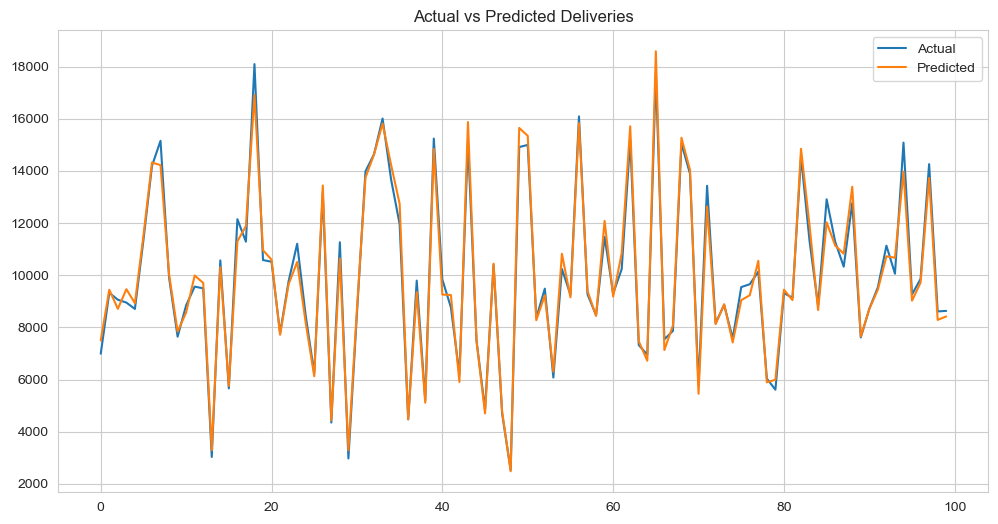

In [58]:
# Actual vs Predicted for the baseline Linear model (first 100 test points)
lr = LinearRegression().fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)

plt.figure(figsize=(12,6))
plt.plot(y_test.values[:100], label="Actual")
plt.plot(y_pred[:100], label="Predicted")

plt.legend()
plt.title("Actual vs Predicted Deliveries")
plt.show()

**Overfitting / Underfitting check:** all three models give very similar, very high R² because `Production_Units` alone explains almost all the variance. Ridge and Lasso (regularised) score about the same as plain Linear Regression — a sign the model is **not overfitting** (low variance). This dataset has a strong, simple signal, so a low-complexity model is enough.

## 10. Cross-Validation

A single train/test split can be lucky or unlucky. **5-fold cross-validation** splits the data five different ways and averages the score, giving a more trustworthy estimate. We wrap scaling + model in a **Pipeline** so the scaler is re-fit inside each fold (preventing leakage).

In [59]:
cv_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  Ridge(alpha=1.0)),
])

cv_scores = cross_val_score(cv_pipeline, X, y, cv=5, scoring="r2")
print("Fold R2 scores:", np.round(cv_scores, 4))
print("Mean CV R2:", round(cv_scores.mean(), 4))
print("Std  CV R2:", round(cv_scores.std(), 4))

Fold R2 scores: [0.9888 0.9884 0.9871 0.9884 0.9891]
Mean CV R2: 0.9883
Std  CV R2: 0.0007


## 11. Hyperparameter Tuning (GridSearchCV)

`alpha` controls how strong the regularisation penalty is in Ridge/Lasso. We use **GridSearchCV** to automatically try several values and pick the one with the best cross-validated score.

In [60]:
tune_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  Ridge()),
])

param_grid = {"model__alpha": [0.01, 0.1, 1, 10, 100]}

grid = GridSearchCV(tune_pipeline, param_grid, cv=5, scoring="r2")
grid.fit(X_train, y_train)

print("Best alpha:", grid.best_params_)
print("Best CV R2:", round(grid.best_score_, 4))

# Evaluate the tuned model on the untouched test set
best_pred = grid.predict(X_test)
print("Tuned model — test R2:", round(r2_score(y_test, best_pred), 4))

Best alpha: {'model__alpha': 1}
Best CV R2: 0.9883
Tuned model — test R2: 0.9883


## 12. Time-Series Forecasting

The regression above predicts deliveries from features. Forecasting is different: we predict **future** deliveries from the **past trend over time**. We first collapse the data into one monthly series of total deliveries.

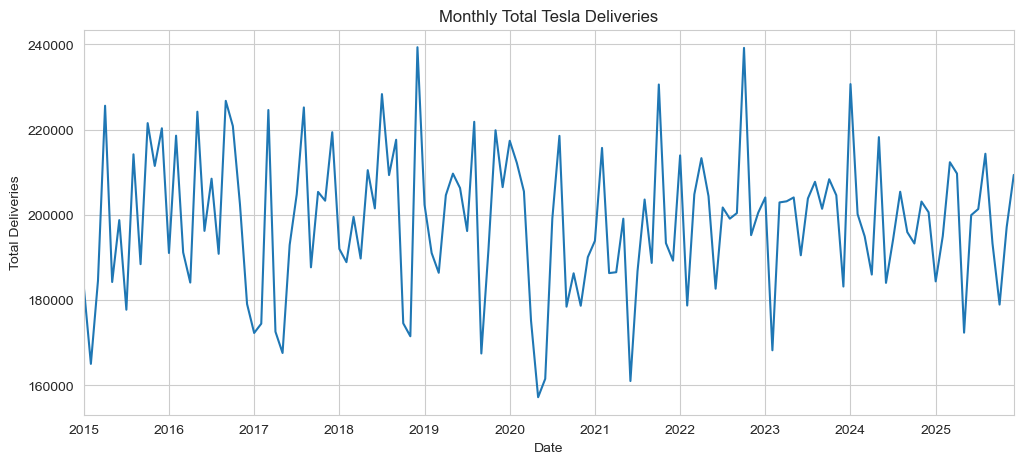

Time series length (months): 132


In [61]:
# Aggregate to monthly total deliveries -> one time series
ts = df.groupby("Date")["Estimated_Deliveries"].sum().sort_index()
ts = ts.asfreq("MS")  

plt.figure(figsize=(12,5))
ts.plot()
plt.title("Monthly Total Tesla Deliveries")
plt.xlabel("Date"); plt.ylabel("Total Deliveries")
plt.show()

print("Time series length (months):", len(ts))

### 12.1 Time-Series Components (Decomposition)
We split the series into **trend**, **seasonality**, and **residual** to understand its structure.

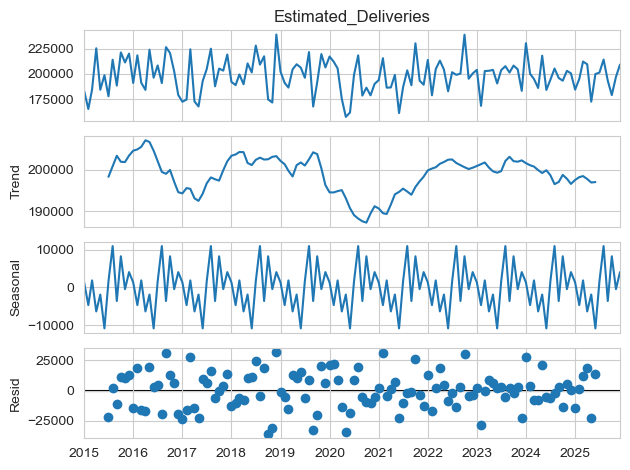

In [62]:
decomposition = seasonal_decompose(ts, model="additive", period=12)

decomposition.plot()
plt.tight_layout()
plt.show()

### 12.2 Stationarity Check (ADF Test)
Many forecasting models assume the series is **stationary** (its statistical properties don't change over time). The **Augmented Dickey-Fuller (ADF)** test checks this: a p-value below 0.05 means the series is stationary.

In [63]:
adf_stat, p_value, *_ = adfuller(ts)
print(f"ADF statistic : {adf_stat:.3f}")
print(f"p-value       : {p_value:.4f}")
print("Result        :", "Stationary" if p_value < 0.05 else "Non-stationary (may need differencing)")

ADF statistic : -8.881
p-value       : 0.0000
Result        : Stationary


### 12.3 Lag Features & Rolling Statistics
- **Lag features** use previous months' values as predictors (e.g. last month, two months ago).  
- **Rolling statistics** (moving average / std) smooth the series and reveal short-term trends.

In [64]:
ts_features = ts.to_frame("Deliveries")
ts_features["lag_1"] = ts_features["Deliveries"].shift(1)
ts_features["lag_2"] = ts_features["Deliveries"].shift(2)
ts_features["rolling_mean_3"] = ts_features["Deliveries"].rolling(window=3).mean()
ts_features["rolling_std_3"]  = ts_features["Deliveries"].rolling(window=3).std()

ts_features.head(8)

,Deliveries,lag_1,lag_2,rolling_mean_3,rolling_std_3
Date,,,,,
2015-01-01,183180,NaN,NaN,NaN,NaN
2015-02-01,165053,183180.0,NaN,NaN,NaN
2015-03-01,184567,165053.0,183180.0,177600.000000,10888.128811
2015-04-01,225623,184567.0,165053.0,191747.666667,30916.867651
2015-05-01,184264,225623.0,184567.0,198151.333333,23791.643582
2015-06-01,198787,184264.0,225623.0,202891.333333,20982.752068
2015-07-01,177759,198787.0,184264.0,186936.666667,10765.758512
2015-08-01,214223,177759.0,198787.0,196923.000000,18303.324725


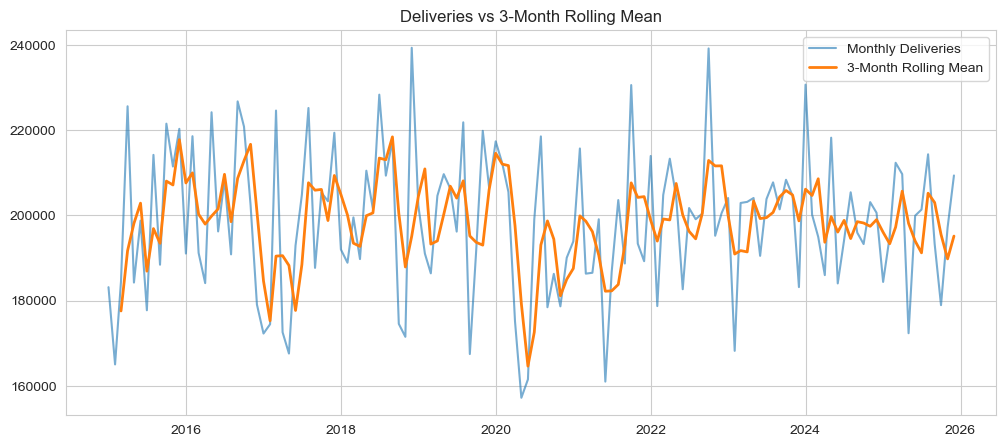

In [28]:
# Visualise the 3-month rolling mean against the raw series
plt.figure(figsize=(12,5))
plt.plot(ts.index, ts.values, label="Monthly Deliveries", alpha=0.6)
plt.plot(ts_features.index, ts_features["rolling_mean_3"], label="3-Month Rolling Mean", linewidth=2)
plt.legend()
plt.title("Deliveries vs 3-Month Rolling Mean")
plt.show()

### 12.4 Chronological Split & ARIMA Forecast
For time series we must **not** shuffle — the test set has to come *after* the training set in time. We train on all months except the last 12, then forecast those 12 months and compare with the actual values.

In [29]:
# Chronological split: last 12 months = test
train_ts = ts[:-12]
test_ts  = ts[-12:]
print("Train months:", len(train_ts), " Test months:", len(test_ts))

# Fit an ARIMA model 
arima = ARIMA(train_ts, order=(1,1,1)).fit()

# Forecast the 12 test months
forecast = arima.forecast(steps=12)

# Evaluate
ts_mae  = mean_absolute_error(test_ts, forecast)
ts_rmse = np.sqrt(mean_squared_error(test_ts, forecast))
print(f"Forecast MAE : {ts_mae:.2f}")
print(f"Forecast RMSE: {ts_rmse:.2f}")

Train months: 120  Test months: 12
Forecast MAE : 10504.31
Forecast RMSE: 13046.16


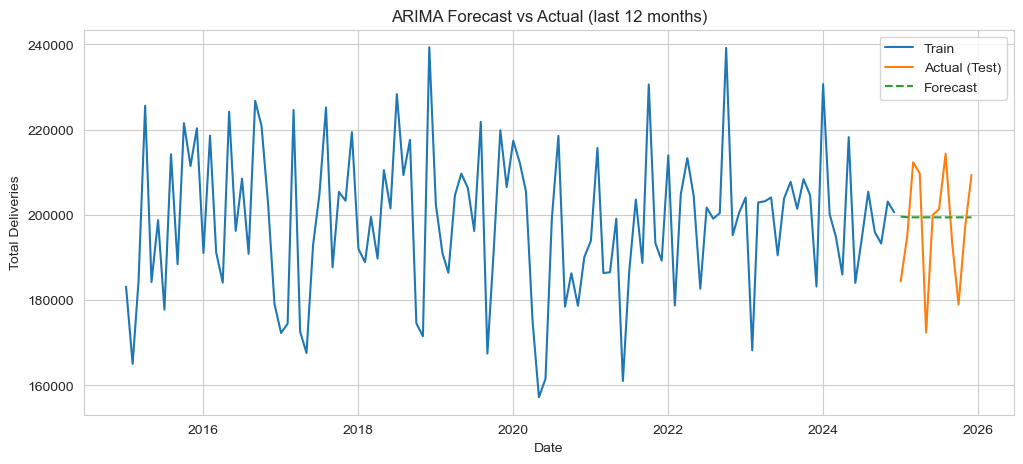

In [30]:
# Plot actual vs forecast
plt.figure(figsize=(12,5))
plt.plot(train_ts.index, train_ts.values, label="Train")
plt.plot(test_ts.index,  test_ts.values,  label="Actual (Test)")
plt.plot(test_ts.index,  forecast.values, label="Forecast", linestyle="--")
plt.legend()
plt.title("ARIMA Forecast vs Actual (last 12 months)")
plt.xlabel("Date"); plt.ylabel("Total Deliveries")
plt.show()

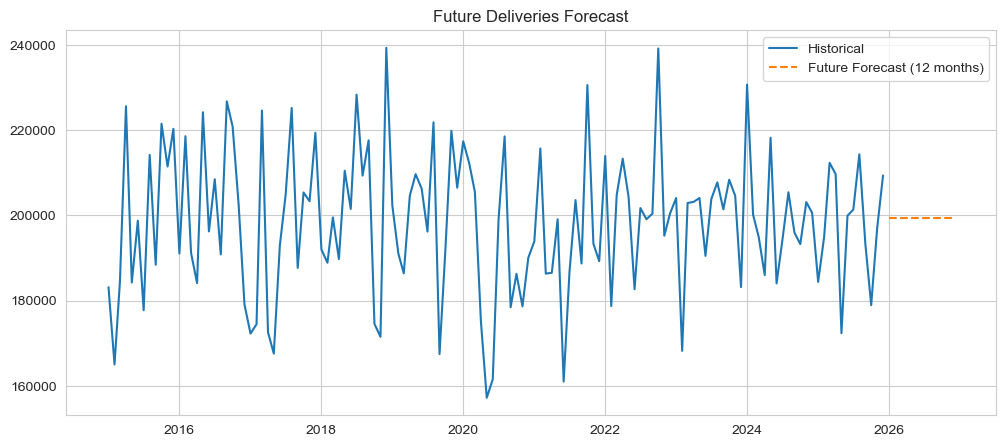

2026-01-01    199439.547453
2026-02-01    199439.547453
2026-03-01    199439.547453
2026-04-01    199439.547453
2026-05-01    199439.547453
2026-06-01    199439.547453
2026-07-01    199439.547453
2026-08-01    199439.547453
2026-09-01    199439.547453
2026-10-01    199439.547453
2026-11-01    199439.547453
2026-12-01    199439.547453
Freq: MS, Name: predicted_mean, dtype: float64

In [31]:
# Forecast the NEXT 12 months beyond the dataset
future = arima.forecast(steps=24)[-12:]

plt.figure(figsize=(12,5))
plt.plot(ts.index, ts.values, label="Historical")
plt.plot(future.index, future.values, label="Future Forecast (12 months)", linestyle="--")
plt.legend()
plt.title("Future Deliveries Forecast")
plt.show()

future

## 13. Conclusion

**Regression findings**
- `Production_Units` is the dominant predictor of deliveries (~0.99 correlation).  
- Linear, Ridge, and Lasso all achieve a very high R², and regularisation didn't change much — the signal is strong and simple, so the model is not overfitting.  
- We removed leaky features (`CO2_Saved_tons`, `Production_Efficiency`) so the model learns an honest relationship.  
- Cross-validation confirmed the score is stable across folds; GridSearchCV selected the best `alpha`.

**Time-series findings**
- The monthly delivery series was decomposed into trend + seasonality + residual.  
- The ADF test assessed stationarity; lag and rolling features described short-term behaviour.  
- An ARIMA model, trained with a chronological split, produced a 12-month forecast.
